# SO / Planck / LiteBIRD comparison + unified constraints

This notebook can either **load** precomputed Fisher pickles or **recompute** them.

Pickles:
- `../fisher_data/so_fisher_all.pkl` (SO + PlanckLite fishers)
- `../fisher_data/lb_fisher_10.pkl` (LiteBIRD fishers)

By default it will **not recompute** if the files already exist.


In [1]:
# --- environment helpers (HPC-friendly) ---
import os
import sys
from pathlib import Path

In [2]:
# Keep matplotlib caches out of $HOME
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import utils

In [3]:
import sys
sys.path.append("../")
sys.path.append("../cosmocast_makelik/")
sys.path.append("../cosmocast_makelik/multi_freq_liq")

In [4]:
# compute_cls is needed for COMBINATION_MODE in {'joint_cov','ell_by_ell'}
from iso_theory import compute_cls


In [6]:
# --- combination configuration ---
# Existing default is 'fisher_sum'. New options: 'joint_cov', 'ell_by_ell'.
year_tag = '10yr'
COMBINATION_MODE = 'ell_by_ell'
ELL_BY_ELL_POLICY = 'min_noise'
USE_ISO_SIGNAL_IN_COV = True
PLANCK_LIKELIHOOD_MODE = 'TTTEEE_lowE'  # 'pliklite_lowT' or 'TTTEEE_lowE' (tau prior approximation)
PLANCK_TAU_PRIOR_SIGMA = 0.007
USE_STANDARD_LCDM_AMPLITUDE = False  # only used when recomputing pickles
USE_NS = False  # only used when recomputing pickles
print('PLANCK_LIKELIHOOD_MODE =', PLANCK_LIKELIHOOD_MODE)
print('COMBINATION_MODE =', COMBINATION_MODE)
print('ELL_BY_ELL_POLICY =', ELL_BY_ELL_POLICY)
print('USE_ISO_SIGNAL_IN_COV =', USE_ISO_SIGNAL_IN_COV)

RUN_TAG = utils.make_run_tag(
    year_tag=year_tag,
    combination_mode=COMBINATION_MODE,
    use_iso_signal_in_cov=USE_ISO_SIGNAL_IN_COV,
    planck_likelihood_mode=PLANCK_LIKELIHOOD_MODE,
    planck_tau_prior_sigma=PLANCK_TAU_PRIOR_SIGMA,
    ell_by_ell_policy=ELL_BY_ELL_POLICY,
    use_standard_lcdm_amplitude=USE_STANDARD_LCDM_AMPLITUDE,
    use_ns=USE_NS,
)
RUN_TAG += "-fixed"
print('RUN_TAG =', RUN_TAG)


PLANCK_LIKELIHOOD_MODE = TTTEEE_lowE
COMBINATION_MODE = ell_by_ell
ELL_BY_ELL_POLICY = min_noise
USE_ISO_SIGNAL_IN_COV = True
RUN_TAG = 10yr_ellbyell_plancklowE-tauprior0p007-fixed


In [7]:
# --- paths + recompute switches ---
# Set these True only when you explicitly want to regenerate the pickles.
RECOMPUTE_SO_FISHER_ALL = False
RECOMPUTE_LB_FISHERS    = False

SO_FISHER_PATH_DEFAULT = Path('..') / 'fisher_data' / 'so_fisher_all.pkl'
LB_FISHER_PATH_DEFAULT = Path('..') / 'fisher_data' / 'lb_fisher_10.pkl'
SO_FISHER_PATH_TAGGED  = Path('..') / 'fisher_data' / f'so_fisher_all_{RUN_TAG}.pkl'
LB_FISHER_PATH_TAGGED  = Path('..') / 'fisher_data' / f'lb_fisher_{RUN_TAG}.pkl'

# Use tagged outputs whenever RUN_TAG differs from the legacy year_tag,
# or whenever recompute is requested. Fall back to legacy pickles only
# when RUN_TAG==year_tag and we are not recomputing.
if RUN_TAG == year_tag and not RECOMPUTE_SO_FISHER_ALL:
    SO_FISHER_PATH = SO_FISHER_PATH_DEFAULT
else:
    SO_FISHER_PATH = SO_FISHER_PATH_TAGGED

if RUN_TAG == year_tag and not RECOMPUTE_LB_FISHERS:
    LB_FISHER_PATH = LB_FISHER_PATH_DEFAULT
else:
    LB_FISHER_PATH = LB_FISHER_PATH_TAGGED

In [8]:
# --- (optional) recompute SO + PlanckLite fisher pickle ---
# Requires `classy` (CLASS) and `cobaya`.

if SO_FISHER_PATH.exists() and not RECOMPUTE_SO_FISHER_ALL:
    print('Found', SO_FISHER_PATH, '- not recomputing.')
else:
    out = utils.compute_so_fisher_all(
        output_path=SO_FISHER_PATH,
        planck_likelihood_mode=PLANCK_LIKELIHOOD_MODE,
        planck_tau_prior_sigma=PLANCK_TAU_PRIOR_SIGMA,
        use_standard_lcdm_amplitude=USE_STANDARD_LCDM_AMPLITUDE,
        use_ns=USE_NS,
    )
    print('Wrote', out)


[load_planck_pliklite_data] Prepended Planck low-ell TT bins (ell<30).
[compute_so_fisher_all] param_list (legacy binned) = ['omega_b', 'omega_cdm', 'h', 'tau_reio', 'P_RR_1', 'P_RR_2']
[compute_so_fisher_all] SO covariance built from adiabatic fiducial spectra (iso_mode=None).
[compute_so_fisher_all] WARNING: PLANCK_LIKELIHOOD_MODE='TTTEEE_lowE' implemented via tau prior sigma=0.007 (approximation; no true lowE bandpowers).
[compute_so_fisher_all] SO covariance built from iso fiducial spectra (iso_mode=cdi).
[compute_so_fisher_all] WARNING: PLANCK_LIKELIHOOD_MODE='TTTEEE_lowE' implemented via tau prior sigma=0.007 (approximation; no true lowE bandpowers).
[compute_so_fisher_all] SO covariance built from iso fiducial spectra (iso_mode=nid).
[compute_so_fisher_all] WARNING: PLANCK_LIKELIHOOD_MODE='TTTEEE_lowE' implemented via tau prior sigma=0.007 (approximation; no true lowE bandpowers).
[compute_so_fisher_all] SO covariance built from iso fiducial spectra (iso_mode=niv).
[compute_so_f

In [9]:
# --- (optional) recompute LiteBIRD fisher pickle ---
# Requires `classy` (CLASS). If CLASS isn't available in your kernel,
# leave RECOMPUTE_LB_FISHERS=False and use the precomputed pickle.

if LB_FISHER_PATH.exists() and not RECOMPUTE_LB_FISHERS:
    print('Found', LB_FISHER_PATH, '- not recomputing.')
else:
    utils.compute_litebird_fisher_grids(
        output_path=LB_FISHER_PATH,
        use_standard_lcdm_amplitude=USE_STANDARD_LCDM_AMPLITUDE,
        use_ns=USE_NS,
    )


[compute_litebird_fisher_grids] LB covariance built from adiabatic fiducial spectra (iso_mode=None).
[compute_litebird_fisher_grids] LB covariance built from iso fiducial spectra (iso_mode=cdi).
[compute_litebird_fisher_grids] LB covariance built from iso fiducial spectra (iso_mode=nid).
[compute_litebird_fisher_grids] LB covariance built from iso fiducial spectra (iso_mode=niv).
[compute_litebird_fisher_grids] LB covariance built from adiabatic fiducial spectra (iso_mode=None).
[compute_litebird_fisher_grids] LB covariance built from iso fiducial spectra (iso_mode=cdi).
[compute_litebird_fisher_grids] LB covariance built from iso fiducial spectra (iso_mode=nid).
[compute_litebird_fisher_grids] LB covariance built from iso fiducial spectra (iso_mode=niv).
[compute_litebird_fisher_grids] LB covariance built from adiabatic fiducial spectra (iso_mode=None).
[compute_litebird_fisher_grids] LB covariance built from iso fiducial spectra (iso_mode=cdi).
[compute_litebird_fisher_grids] LB cova

In [10]:
# --- load pickles (after optional recompute) ---

theta_full = utils.THETA_FULL
so_fisher_all = utils.load_so_fisher_all(SO_FISHER_PATH)
muci = utils.load_litebird_grids(LB_FISHER_PATH)

corr_plot = ['pcor', 'ucor', 'acor']
iso_plot = [None, 'cdi', 'nid', 'niv']
year_tag = '10yr'

In [11]:
# --- compute + save Planck-only / SO-only / LiteBIRD-only / unified constraints ---

utils.compare_and_save_constraints(
    so_fisher_all=so_fisher_all,
    muci=muci,
    theta_full=theta_full,
    corr_plot=corr_plot,
    iso_plot=iso_plot,
    year_tag=year_tag,
    combination_mode=COMBINATION_MODE,
    ell_by_ell_policy=ELL_BY_ELL_POLICY,
    use_iso_signal_in_cov=USE_ISO_SIGNAL_IN_COV,
    compute_cls=compute_cls if COMBINATION_MODE in {'joint_cov','ell_by_ell'} else None,
    planck_likelihood_mode=PLANCK_LIKELIHOOD_MODE,
    planck_tau_prior_sigma=PLANCK_TAU_PRIOR_SIGMA,
    out_year_tag=RUN_TAG,
    out_base='images/unified_constraints',
    skip_existing=True,
    write_tables=True,
    write_corr=True,
    write_triangles=True,
    write_overlays=True,
)

out_year_tag = year_tag
if COMBINATION_MODE == 'joint_cov':
    out_year_tag = f"{year_tag}_jointcov" if USE_ISO_SIGNAL_IN_COV else f"{year_tag}_jointcov_noisosignal"
elif COMBINATION_MODE == 'ell_by_ell':
    out_year_tag = f"{year_tag}_ellbyell" if USE_ISO_SIGNAL_IN_COV else f"{year_tag}_ellbyell_noisosignal"
print('Wrote outputs under:', Path('images/unified_constraints') / RUN_TAG)

[compare_and_save_constraints] WARNING: PLANCK_LIKELIHOOD_MODE='TTTEEE_lowE' implemented via tau prior sigma=0.007 (approximation; no true lowE bandpowers).
[compare_and_save_constraints] combination_mode=ell_by_ell policy=min_noise
[compare_and_save_constraints] ell_by_ell f_sky mapping active (per-ell).
[compare_and_save_constraints] corr=pcor iso=cdi
[compare_and_save_constraints] TT assignments: {'Planck': 194, 'LiteBIRD': 17, 'SO SAT': 0, 'SO LAT': 260}
[compare_and_save_constraints] TE assignments: {'Planck': 194, 'LiteBIRD': 17, 'SO SAT': 0, 'SO LAT': 0}
[compare_and_save_constraints] EE assignments: {'Planck': 175, 'LiteBIRD': 3, 'SO SAT': 35, 'SO LAT': 260}
[compare_and_save_constraints] WARNING: PLANCK_LIKELIHOOD_MODE='TTTEEE_lowE' implemented via tau prior sigma=0.007 (approximation; no true lowE bandpowers).
[compare_and_save_constraints] combination_mode=ell_by_ell policy=min_noise
[compare_and_save_constraints] ell_by_ell f_sky mapping active (per-ell).
[compare_and_save_

## Additional (non-Fisher) plots

These reproduce the other plot types from the original script:
- unified noise curves (TT + EE)
- covariance-diagonal diagnostic plots (TT, EE, TE)

They **require** `classy` (CLASS) and `cobaya` (PlikLite loader).


In [12]:
yr = 10
NOISE_TAG = utils.make_run_tag(
    year_tag=yr,
    combination_mode=COMBINATION_MODE,
    use_iso_signal_in_cov=USE_ISO_SIGNAL_IN_COV,
    planck_likelihood_mode=PLANCK_LIKELIHOOD_MODE,
    planck_tau_prior_sigma=PLANCK_TAU_PRIOR_SIGMA,
    ell_by_ell_policy=ELL_BY_ELL_POLICY,
)
NOISE_TAG += "-fixed"
print('NOISE_TAG =', NOISE_TAG)


NOISE_TAG = 10_ellbyell_plancklowE-tauprior0p007-fixed


In [13]:
import nonfisher_plots

RECOMPUTE_NONFISHER_PLOTS = True
NONFISHER_OUTDIR = Path(f'images/non_fisher_{NOISE_TAG}')

# If outputs already exist and recompute is False, do nothing.
# (Files are written under images/non_fisher/y<year>/)
if RECOMPUTE_NONFISHER_PLOTS:
    so_lik_unif = nonfisher_plots.compute_and_save_noise_and_cov_plots(
        out_dir=NONFISHER_OUTDIR,
        year=yr,
        fsky_lat=0.4,
        skip_existing=True,
    )
else:
    print('Skipping non-Fisher plot generation (set RECOMPUTE_NONFISHER_PLOTS=True to run).')


[load_planck_pliklite_data] Prepended Planck low-ell TT bins (ell<30).


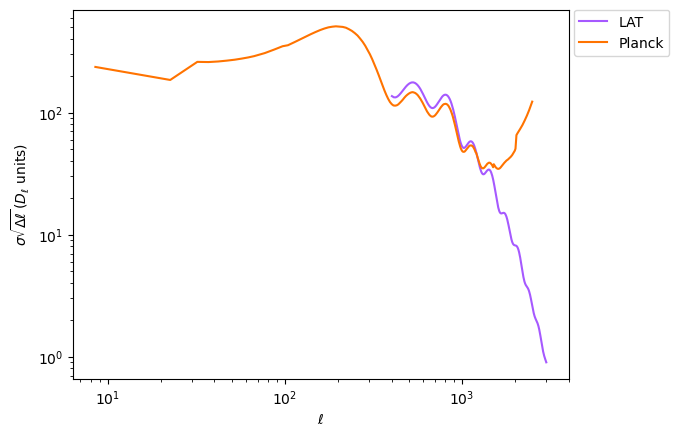

Wrote: images/non_fisher_10_ellbyell_plancklowE-tauprior0p007-fixed/y10/cov_diag_TT_split.pdf


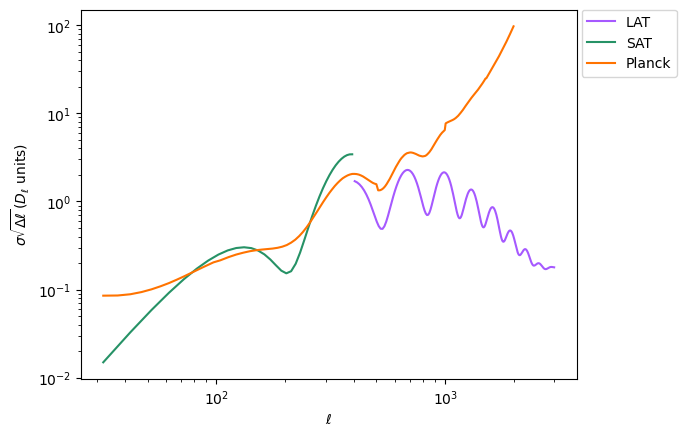

Wrote: images/non_fisher_10_ellbyell_plancklowE-tauprior0p007-fixed/y10/cov_diag_EE_split.pdf


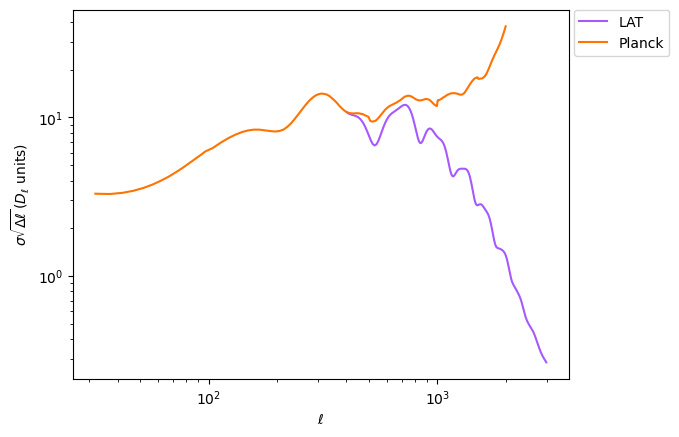

Wrote: images/non_fisher_10_ellbyell_plancklowE-tauprior0p007-fixed/y10/cov_diag_TE_split.pdf


In [15]:
# --- additional covariance diagnostic plots (total vs CV/noise components) ---
# Uses `so_lik_unif` returned by `nonfisher_plots.compute_and_save_noise_and_cov_plots(...)`

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from colors import assign_colors, EXP_TO_FAMILY, FAMILY_PALETTES

def _knox_prefactor(ell, fsky, cross=False):
    """sqrt(dell)*sigma = (signal) * sqrt(k / [(2l+1) fsky]), k=2 auto, k=1 cross."""
    k = 1.0 if cross else 2.0
    return np.sqrt(k / ((2.0 * ell + 1.0) * fsky))

DISPLAY_NAMES = {
    "LAT": "LAT",
    "LAT_pol": "LAT",
    "LAT_cross": "LAT",
    "SAT": "SAT",
    "PK": "Planck",
    "PK_pol": "Planck",
    "PK_cross": "Planck",
    "PK_lite": "Planck",
    "PK_lite_pol": "Planck",
    "PK_lite_cross": "Planck",
    "LB": "LiteBIRD",
    "LB_TT": "LiteBIRD",
}

def _as_dell_array(dell, n):
    dell_arr = np.asarray(dell, dtype=float)
    if dell_arr.ndim == 0:
        return np.full(n, float(dell_arr))
    return dell_arr

def plot_cov(exp_temp_arr, cell_type, so_lik_unif, *, pref=True, include_cv=False, out_dir=None):
    """
    include_cv=False: solid total sigma*sqrt(dell) per experiment.
    include_cv=True : also plot CV-only (dashed) and noise-only (dotted) per experiment
                      in shades from the same family palette.
                      For TE, only the dashed pure-CV-limit line is added.
    """
    is_cross = (cell_type == "TE")
    colors = assign_colors(exp_temp_arr)

    def _shades_for(exp):
        family = EXP_TO_FAMILY[exp]
        palette = FAMILY_PALETTES[family]
        solid = colors[exp]
        solid_idx = palette.index(solid) if solid in palette else 0
        dashed_idx = (solid_idx + 1) % len(palette)
        dotted_idx = (solid_idx + 2) % len(palette)
        return palette[dashed_idx], palette[dotted_idx]

    out_dir = Path(out_dir) if out_dir is not None else (NONFISHER_OUTDIR / f"y{yr}")
    out_dir.mkdir(parents=True, exist_ok=True)

    plt.figure()
    for exp in exp_temp_arr:
        d = so_lik_unif["data"][exp]
        meta = so_lik_unif["metadata"][exp]
        ell = np.asarray(d["ell"], dtype=float)
        n_ell_pts = len(ell)

        dell_arr = _as_dell_array(d.get("dell", 1.0), n_ell_pts)
        cov = np.asarray(d["cov"], dtype=float)
        c_ell = np.asarray(d["c_ell"], dtype=float)
        n_ell = np.asarray(d["n_ell"], dtype=float)
        fsky = float(meta["fsky"])
        color = colors[exp]

        dl_fac = ell * (ell + 1.0) / (2.0 * np.pi) if pref else 1.0

        # total: sigma*sqrt(dell) = sqrt(Var * dell)
        err_total = np.sqrt(cov * dell_arr) * dl_fac
        plt.plot(ell, err_total, label=DISPLAY_NAMES.get(exp, exp), color=color, linestyle="-")

        if not include_cv:
            continue

        dashed_color, dotted_color = _shades_for(exp)
        k_pref = _knox_prefactor(ell, fsky, cross=is_cross)

        if not is_cross:
            cv_err = np.abs(c_ell) * k_pref * dl_fac
            noise_err = np.abs(n_ell) * k_pref * dl_fac
            plt.plot(ell, cv_err, color=dashed_color, linestyle="--")
            plt.plot(ell, noise_err, color=dotted_color, linestyle=":")
        else:
            auto_lookup = {
                "LAT_cross": ("LAT", "LAT_pol"),
                "PK_cross": ("PK", "PK_pol"),
                "PK_lite_cross": ("PK_lite", "PK_lite_pol"),
            }
            if exp not in auto_lookup:
                continue
            tt_key, ee_key = auto_lookup[exp]
            if tt_key not in so_lik_unif["data"] or ee_key not in so_lik_unif["data"]:
                continue
            c_tt = np.asarray(so_lik_unif["data"][tt_key]["c_ell"], dtype=float)
            c_ee = np.asarray(so_lik_unif["data"][ee_key]["c_ell"], dtype=float)
            n = len(ell)
            c_tt = c_tt[:n]
            c_ee = c_ee[:n]
            cv_err = np.sqrt(c_ell**2 + c_tt * c_ee) * k_pref * dl_fac
            plt.plot(ell, cv_err, color=dashed_color, linestyle="--")

    if include_cv:
        plt.plot([], [], color="black", linestyle="--", label=r"Cosmic Variance")
        if not is_cross:
            plt.plot([], [], color="black", linestyle=":", label="Noise Contribution")

    ylabel = (
        r"$\sigma \sqrt{\Delta \ell} \, (D_\ell\ \mathrm{units})$"
        if pref
        else r"$\sigma \sqrt{\Delta \ell} \, (C_\ell\ \mathrm{units})$"
    )
    plt.ylabel(ylabel)
    plt.xlabel(r"$\ell$")
    plt.loglog()
    plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)

    suffix = "_cv" if include_cv else ""
    out_path = out_dir / f"cov_diag_{cell_type}{suffix}_split.pdf"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Wrote:", out_path)

# --- call sites ---
if "so_lik_unif" not in globals() or so_lik_unif is None:
    print("Skipping covariance split plots: `so_lik_unif` is not defined (requires `classy`).")
else:
    WITH_PK_LITE = True
    include_cv = False  # set True for dashed/dotted decomposition

    if WITH_PK_LITE:
        plot_cov(["LAT", "PK_lite"], "TT", so_lik_unif, include_cv=include_cv)
        plot_cov(["LAT_pol", "SAT", "PK_lite_pol"], "EE", so_lik_unif, include_cv=include_cv)
        plot_cov(["LAT_cross", "PK_lite_cross"], "TE", so_lik_unif, include_cv=include_cv)
    else:
        plot_cov(["LAT"], "TT", so_lik_unif, include_cv=include_cv)
        plot_cov(["LAT_pol", "SAT"], "EE", so_lik_unif, include_cv=include_cv)
        plot_cov(["LAT_cross"], "TE", so_lik_unif, include_cv=include_cv)


## Some tests for debugging

[ell_by_ell] counts TT: {'Planck': 194, 'LiteBIRD': 17, 'SO SAT': 0, 'SO LAT': 260}
[ell_by_ell] counts TE: {'Planck': 194, 'LiteBIRD': 17, 'SO SAT': 0, 'SO LAT': 0}
[ell_by_ell] counts EE: {'Planck': 175, 'LiteBIRD': 3, 'SO SAT': 35, 'SO LAT': 260}
metadata: {'combination_mode': 'ell_by_ell', 'ell_by_ell_policy': 'min_noise', 'use_iso_signal_in_cov': True, 'iso_mode': 'cdi', 'counts': {'TT': {'Planck': 194, 'LiteBIRD': 17, 'SO SAT': 0, 'SO LAT': 260}, 'TE': {'Planck': 194, 'LiteBIRD': 17, 'SO SAT': 0, 'SO LAT': 0}, 'EE': {'Planck': 175, 'LiteBIRD': 3, 'SO SAT': 35, 'SO LAT': 260}}, 'n_ell': {'TT': 471, 'TE': 211, 'EE': 473}}


,Fiducial,sigma,S/N
omega_b,0.02237,0.000039,579.554355
omega_cdm,0.11933,0.000152,783.682645
h,0.67660,0.000837,808.249547
tau_reio,0.05610,0.001804,31.100608
P_RR_1,23.00000,0.182828,125.801115
P_RR_2,23.00000,0.081133,283.485723
P_II_1,15.00000,1.156928,12.965368
P_II_2,15.00000,1.700010,8.823478


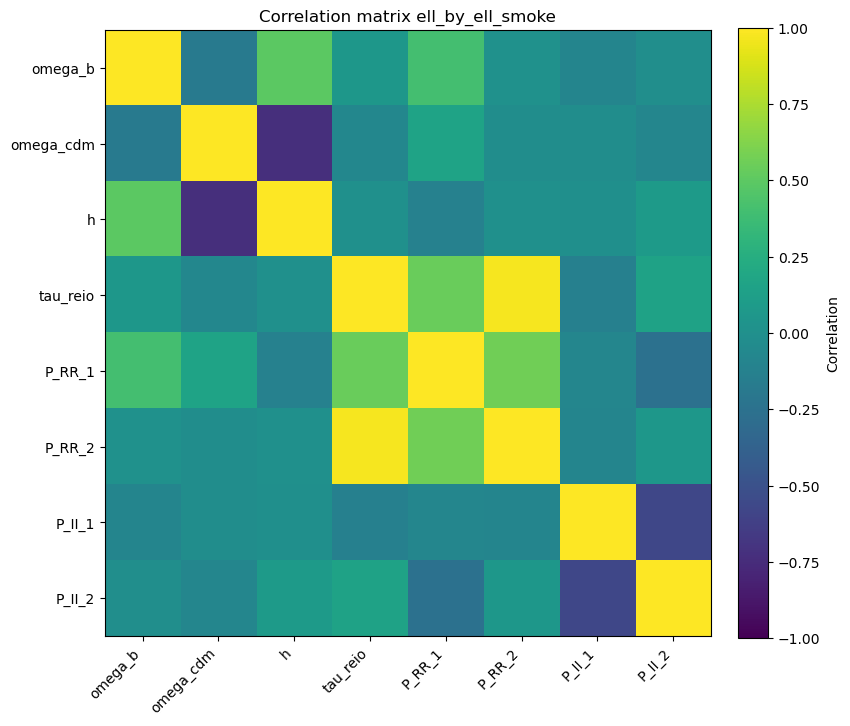

In [26]:
# Quick sanity check: one case's unified sigma table
corr='pcor'
iso='cdi'

pk = so_fisher_all[corr]['PK_Lite'][iso][year_tag]
so = so_fisher_all[corr]['SO'][iso][year_tag]
lb = muci[corr]['LB'][iso][year_tag]

if COMBINATION_MODE == 'fisher_sum':
    unified = pk.combine(so).combine(lb)
elif COMBINATION_MODE == 'joint_cov':
    unified = utils.fisher_from_joint_covariance(
        theta0=dict(theta_full[corr]['theta0']),
        corr_dict=dict(theta_full[corr].get('corr', {}) or {}),
        iso_mode=iso,
        compute_cls=compute_cls,
        experiments={'Planck': pk.bands, 'SO': so.bands, 'LiteBIRD': lb.bands},
        param_list=list(pk.param_list),
        steps=utils._default_steps_for_param_list(pk.param_list),
        scaled10_params=utils._scaled10_params_for_param_list(pk.param_list),
        spectra=('TT','TE','EE'),
        use_iso_signal_in_cov=USE_ISO_SIGNAL_IN_COV,
        verbose=True,
    )
else:
    unified = utils.fisher_from_ell_by_ell_effective_experiment(
        theta0=dict(theta_full[corr]['theta0']),
        corr_dict=dict(theta_full[corr].get('corr', {}) or {}),
        iso_mode=iso,
        compute_cls=compute_cls,
        planck_bands=pk.bands,
        so_bands=so.bands,
        litebird_bands=lb.bands,
        param_list=list(pk.param_list),
        steps=utils._default_steps_for_param_list(pk.param_list),
        scaled10_params=utils._scaled10_params_for_param_list(pk.param_list),
        use_iso_signal_in_cov=USE_ISO_SIGNAL_IN_COV,
        ell_by_ell_policy=ELL_BY_ELL_POLICY,
        verbose=True,
    )
unified = utils.apply_planck_lowE_tau_prior(
    unified,
    planck_likelihood_mode=PLANCK_LIKELIHOOD_MODE,
    tau_prior_sigma=PLANCK_TAU_PRIOR_SIGMA,
)
if PLANCK_LIKELIHOOD_MODE == 'TTTEEE_lowE':
    print('WARNING: TTTEEE_lowE is approximated here by a Gaussian tau prior (no true low-ell EE bandpowers).')
print('metadata:', getattr(unified, 'metadata', {}))
# Minimal plotting smoke check (matplotlib-only)
unified.plot_correlation(exp_name=f'{COMBINATION_MODE}_smoke')
unified.summary_table(theta_full[corr]['theta0'], scaled_params={'P_RR_1','P_RR_2','P_II_1','P_II_2'})


[smoke] ell_by_ell done. F shape: (8, 8)


(<Figure size 860x860 with 2 Axes>,
 <Axes: title={'center': 'Correlation matrix ell_by_ell_smoke'}>)

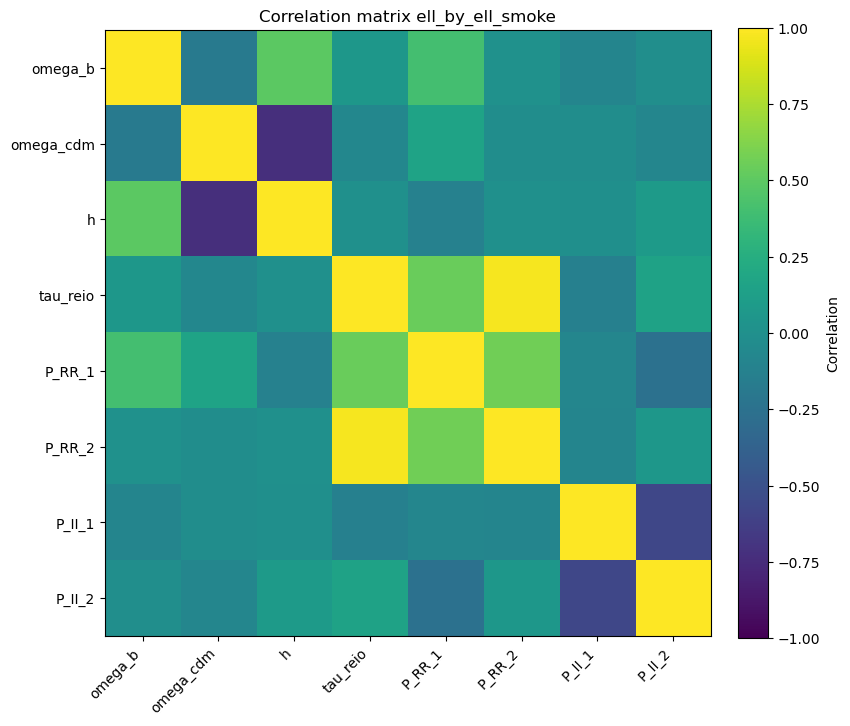

In [27]:
# --- smoke test: one corr/iso, 10yr only (ell_by_ell) ---
corr_smoke = 'pcor'
iso_smoke  = 'cdi'
year_smoke = year_tag
pk = so_fisher_all[corr_smoke]['PK_Lite'][iso_smoke][year_smoke]
so = so_fisher_all[corr_smoke]['SO'][iso_smoke][year_smoke]
lb = muci[corr_smoke]['LB'][iso_smoke][year_smoke]
unified_ell = utils.fisher_from_ell_by_ell_effective_experiment(
    theta0=dict(theta_full[corr_smoke]['theta0']),
    corr_dict=dict(theta_full[corr_smoke].get('corr', {}) or {}),
    iso_mode=iso_smoke,
    compute_cls=compute_cls,
    planck_bands=pk.bands,
    so_bands=so.bands,
    litebird_bands=lb.bands,
    param_list=list(pk.param_list),
    steps=utils._default_steps_for_param_list(pk.param_list),
    scaled10_params=utils._scaled10_params_for_param_list(pk.param_list),
    use_iso_signal_in_cov=USE_ISO_SIGNAL_IN_COV,
    ell_by_ell_policy=ELL_BY_ELL_POLICY,
)
unified_ell = utils.apply_planck_lowE_tau_prior(
    unified_ell,
    planck_likelihood_mode=PLANCK_LIKELIHOOD_MODE,
    tau_prior_sigma=PLANCK_TAU_PRIOR_SIGMA,
)
if PLANCK_LIKELIHOOD_MODE == 'TTTEEE_lowE':
    print('WARNING: TTTEEE_lowE is approximated here by a Gaussian tau prior (no true low-ell EE bandpowers).')
print('[smoke] ell_by_ell done. F shape:', unified_ell.F.shape)
unified_ell.plot_correlation(exp_name='ell_by_ell_smoke')


In [28]:
# --- diagnostics: tau_reio improvement source (adiabatic LCDM, ell_by_ell) ---
import numpy as np

if COMBINATION_MODE != 'ell_by_ell':
    raise RuntimeError("Set COMBINATION_MODE='ell_by_ell' to run this diagnostics section.")

corr_diag = 'pcor'
iso_diag = None
year_diag = year_tag

pk = so_fisher_all[corr_diag]['PK_Lite'][iso_diag][year_diag]
so = so_fisher_all[corr_diag]['SO'][iso_diag][year_diag]
lb = muci[corr_diag]['LB'][iso_diag][year_diag]

param_list = list(pk.param_list)
print('param_list =', param_list)
print('A_s in param_list? ->', 'A_s' in param_list)
print('ln10A_s in param_list? ->', 'ln10A_s' in param_list)
print('n_s in param_list? ->', 'n_s' in param_list)

# Build a fiducial dict compatible with the parameterization used in the pickles
theta0_diag = dict(theta_full[corr_diag]['theta0'])
corr_dict_diag = dict(theta_full[corr_diag].get('corr', {}) or {})
if ('ln10A_s' in param_list) or ('n_s' in param_list):
    theta0_diag = utils._theta0_standard_lcdm(theta0_base=theta_full[corr_diag]['theta0'])
    corr_dict_diag = {}
    print('[diag] Using standard ΛCDM theta0 (ln10A_s/n_s); corr_dict ignored.')

steps = utils._default_steps_for_param_list(param_list)
scaled10 = utils._scaled10_params_for_param_list(param_list)

f_pk = utils.fisher_from_ell_by_ell_effective_experiment(
    theta0=dict(theta0_diag),
    corr_dict=dict(corr_dict_diag),
    iso_mode=iso_diag,
    compute_cls=compute_cls,
    planck_bands=pk.bands,
    so_bands=[],
    litebird_bands=[],
    param_list=param_list,
    steps=steps,
    scaled10_params=scaled10,
    use_iso_signal_in_cov=USE_ISO_SIGNAL_IN_COV,
    ell_by_ell_policy=ELL_BY_ELL_POLICY,
)

f_pk_so = utils.fisher_from_ell_by_ell_effective_experiment(
    theta0=dict(theta0_diag),
    corr_dict=dict(corr_dict_diag),
    iso_mode=iso_diag,
    compute_cls=compute_cls,
    planck_bands=pk.bands,
    so_bands=so.bands,
    litebird_bands=[],
    param_list=param_list,
    steps=steps,
    scaled10_params=scaled10,
    use_iso_signal_in_cov=USE_ISO_SIGNAL_IN_COV,
    ell_by_ell_policy=ELL_BY_ELL_POLICY,
)

f_pk_so_lb = utils.fisher_from_ell_by_ell_effective_experiment(
    theta0=dict(theta0_diag),
    corr_dict=dict(corr_dict_diag),
    iso_mode=iso_diag,
    compute_cls=compute_cls,
    planck_bands=pk.bands,
    so_bands=so.bands,
    litebird_bands=lb.bands,
    param_list=param_list,
    steps=steps,
    scaled10_params=scaled10,
    use_iso_signal_in_cov=USE_ISO_SIGNAL_IN_COV,
    ell_by_ell_policy=ELL_BY_ELL_POLICY,
)

# Apply the Planck lowE handling *after* each total Fisher is constructed.
f_pk = utils.apply_planck_lowE_tau_prior(
    f_pk,
    planck_likelihood_mode=PLANCK_LIKELIHOOD_MODE,
    tau_prior_sigma=PLANCK_TAU_PRIOR_SIGMA,
)
f_pk_so = utils.apply_planck_lowE_tau_prior(
    f_pk_so,
    planck_likelihood_mode=PLANCK_LIKELIHOOD_MODE,
    tau_prior_sigma=PLANCK_TAU_PRIOR_SIGMA,
)
f_pk_so_lb = utils.apply_planck_lowE_tau_prior(
    f_pk_so_lb,
    planck_likelihood_mode=PLANCK_LIKELIHOOD_MODE,
    tau_prior_sigma=PLANCK_TAU_PRIOR_SIGMA,
)

if PLANCK_LIKELIHOOD_MODE == 'TTTEEE_lowE':
    print('WARNING: TTTEEE_lowE is approximated here by a Gaussian tau prior (no true low-ell EE bandpowers).')


def _sigma_tau(f):
    i = f.param_list.index('tau_reio')
    return float(f.sigma[i])

sigma_tau_pk = _sigma_tau(f_pk)
sigma_tau_pk_so = _sigma_tau(f_pk_so)
sigma_tau_pk_so_lb = _sigma_tau(f_pk_so_lb)

print('marginalized sigma(tau_reio):')
print('  Planck only                =', sigma_tau_pk)
print(f'  Planck + SO ({year_diag})           =', sigma_tau_pk_so)
print(f'  Planck + SO ({year_diag}) + LiteBIRD =', sigma_tau_pk_so_lb)

# Sanity checks: adding experiments should not degrade sigma(tau).
_eps = 1e-12
assert sigma_tau_pk_so <= sigma_tau_pk + _eps, (
    f"Sanity check failed: sigma_tau(Planck+SO)={sigma_tau_pk_so} > sigma_tau(Planck)={sigma_tau_pk}"
)
assert sigma_tau_pk_so_lb <= sigma_tau_pk_so + _eps, (
    f"Sanity check failed: sigma_tau(Planck+SO+LiteBIRD)={sigma_tau_pk_so_lb} > sigma_tau(Planck+SO)={sigma_tau_pk_so}"
)


def _cuts_summary(bands, *, label):
    by = {}
    for b in bands:
        ek = str(getattr(b, 'exp_key', ''))
        ct = str(getattr(b, 'cell_type', ''))
        key = (ek, ct)
        ell = np.asarray(getattr(b, 'ell'), dtype=int)
        if ell.size == 0:
            continue
        lo, hi = int(np.min(ell)), int(np.max(ell))
        by.setdefault(key, [10**9, -1])
        by[key][0] = min(by[key][0], lo)
        by[key][1] = max(by[key][1], hi)
    print(f'ell cuts summary: {label}')
    for (ek, ct), (lo, hi) in sorted(by.items()):
        print(f'  {ek:10s}  {ct:2s}:  ell=[{lo},{hi}]')

_cuts_summary(pk.bands, label='Planck (bands used in ell_by_ell)')
_cuts_summary(so.bands, label=f'SO {year_diag} (bands used in ell_by_ell)')
_cuts_summary(lb.bands, label='LiteBIRD (bands used in ell_by_ell)')


param_list = ['omega_b', 'omega_cdm', 'h', 'tau_reio', 'P_RR_1', 'P_RR_2']
A_s in param_list? -> False
ln10A_s in param_list? -> False
n_s in param_list? -> False
marginalized sigma(tau_reio):
  Planck only                = 0.026971773686739014
  Planck + SO (10yr)           = 0.007452603181083062
  Planck + SO (10yr) + LiteBIRD = 0.0023564145735207997
ell cuts summary: Planck (PK_Lite bands)
  PK_Lite  EE: 32 .. 1988
  PK_Lite  TE: 32 .. 1988
  PK_Lite  TT: 8 .. 2492
ell cuts summary: SO SAT
  SAT      EE: 32 .. 392
ell cuts summary: SO LAT (TT)
  LAT      TT: 402 .. 2992
ell cuts summary: SO LAT_pol (EE)
  LAT_pol  EE: 402 .. 2992
ell cuts summary: LiteBIRD
  LB       EE: 2 .. 192
  LB       TE: 2 .. 192
  LB       TT: 2 .. 192
F_tau,tau contributions: Planck only
  total F_tau,tau = 3053320.4547582623
  ell <10   : 79.5675  (frac 0.000)
  ell 10-30 : 553.906  (frac 0.000)
  ell 30-400: 286961  (frac 0.094)
  ell >=400 : 2.76573e+06  (frac 0.906)
  spec EE: 235493  (frac 0.077)
  spe

In [29]:
# --- diagnostics: Planck lowE mode (tau prior approximation) ---
corr_p = 'pcor'
year_p = year_tag
pk_ad = so_fisher_all[corr_p]['PK_Lite'][None][year_p]
print('Planck-only raw sigma(tau_reio) =', pk_ad.sigma[pk_ad.param_list.index('tau_reio')])
pk_ad_lowE = utils.apply_planck_lowE_tau_prior(
    pk_ad,
    planck_likelihood_mode=PLANCK_LIKELIHOOD_MODE,
    tau_prior_sigma=PLANCK_TAU_PRIOR_SIGMA,
)
print('PLANCK_LIKELIHOOD_MODE =', PLANCK_LIKELIHOOD_MODE)
print('Planck-only (with mode) sigma(tau_reio) =', pk_ad_lowE.sigma[pk_ad_lowE.param_list.index('tau_reio')])
print('Expected Planck 2018 TTTEEE+lowE sigma(tau) ~ 0.007 (approx).')
if PLANCK_LIKELIHOOD_MODE == 'TTTEEE_lowE':
    print('WARNING: lowE is approximated here by a Gaussian tau prior (no true low-ell EE bandpowers).')

# --- smoke: standard ΛCDM spectra knobs (A_s, n_s) ---
utils.smoke_test_standard_lcdm_spectra(compute_cls=compute_cls)


Planck-only raw sigma(tau_reio) = 0.006719345879556608
PLANCK_LIKELIHOOD_MODE = TTTEEE_lowE
Planck-only (with mode) sigma(tau_reio) = 0.004847477216957824
Expected Planck 2018 TTTEEE+lowE sigma(tau) ~ 0.007 (approx).
[smoke_test_standard_lcdm_spectra] TT ratio at ell=50 for +1% A_s: 1.0100069825546405
[smoke_test_standard_lcdm_spectra] TT ratio at ell=50 for n_s=0.975: 0.9807272998655133
